In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf

In [4]:
data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
2015-01-05,23.511053,24.042127,23.325178,23.962466,257142000
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000


In [5]:
data["Daily Return"] = data["Close"].pct_change()

data.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400,NaN
2015-01-05,23.511053,24.042127,23.325178,23.962466,257142000,-0.028172
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400,0.000094
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600,0.014022
2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000,0.038422


In [6]:
data["Daily Return"].describe()

count    2515.000000
mean        0.001088
std         0.017929
min        -0.128647
25%        -0.007326
50%         0.001000
75%         0.010142
max         0.119808
Name: Daily Return, dtype: float64

In [7]:
daily_volatility = data["Daily Return"].std()

daily_volatility

np.float64(0.01792922181130969)

In [8]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility

np.float64(0.28461757268184285)

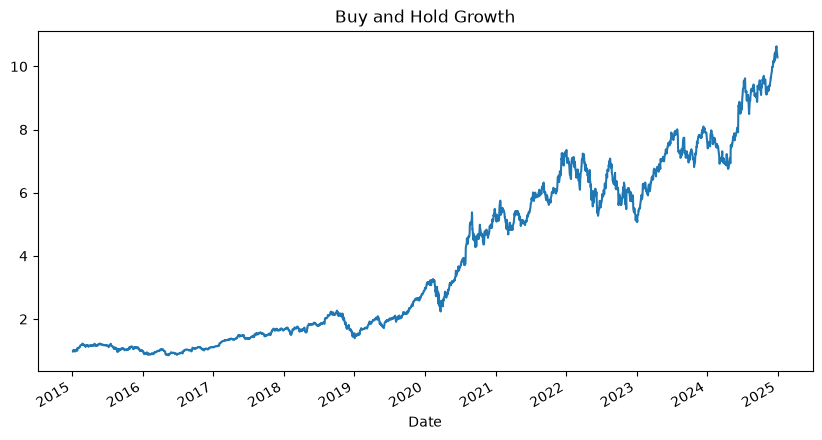

In [9]:
cumulative_return = (1 + data["Daily Return"]).cumprod()

cumulative_return.plot(figsize=(10,5))
plt.title("Buy and Hold Growth")
plt.show()

In [10]:
data["50 Day MA"] = data["Close"].rolling(window=50).mean()

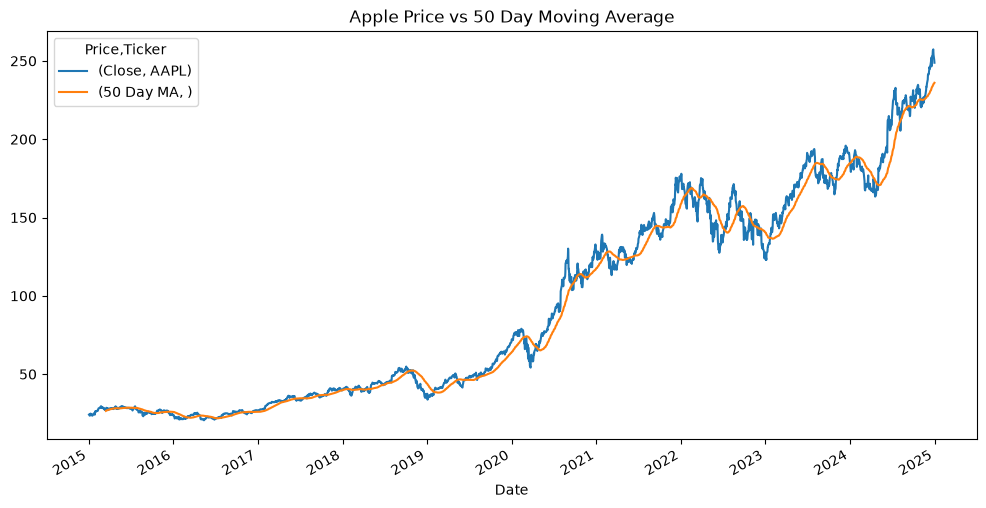

In [11]:
data[["Close","50 Day MA"]].plot(figsize=(12,6))
plt.title("Apple Price vs 50 Day Moving Average")
plt.show()

In [12]:
data["Signal"] = 0

data.loc[data["Close"] > data["50 Day MA"], "Signal"] = 1

data.loc[data["Close"] < data["50 Day MA"], "Signal"] = 0

ValueError: Operands are not aligned. Do `left, right = left.align(right, axis=1)` before operating.

In [13]:
data.columns

MultiIndex([(       'Close', 'AAPL'),
            (        'High', 'AAPL'),
            (         'Low', 'AAPL'),
            (        'Open', 'AAPL'),
            (      'Volume', 'AAPL'),
            ('Daily Return',     ''),
            (   '50 Day MA',     ''),
            (      'Signal',     '')],
           names=['Price', 'Ticker'])

In [14]:
data.columns = data.columns.get_level_values(0)

In [15]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily Return', '50 Day MA',
       'Signal'],
      dtype='str', name='Price')

In [16]:
data["Signal"] = 0

data.loc[data["Close"] > data["50 Day MA"], "Signal"] = 1

data.loc[data["Close"] < data["50 Day MA"], "Signal"] = 0

In [17]:
data.tail()

Price,Close,High,Low,Open,Volume,Daily Return,50 Day MA,Signal
Date,,,,,,,,
2024-12-24,256.560791,256.570707,253.669247,253.867989,23234700,0.011478,234.325891,1
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,234.831201,1
2024-12-27,253.967361,257.057633,251.453425,256.193131,42355300,-0.013242,235.309440,1
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,-0.013263,235.712964,1
2024-12-31,248.830200,251.672044,247.846480,250.837380,39480700,-0.007058,236.024539,1


In [18]:
data["Strategy Return"] = data["Signal"].shift(1) * data["Daily Return"]

In [19]:
data["Buy Hold"] = (1 + data["Daily Return"]).cumprod()

data["Strategy"] = (1 + data["Strategy Return"]).cumprod()

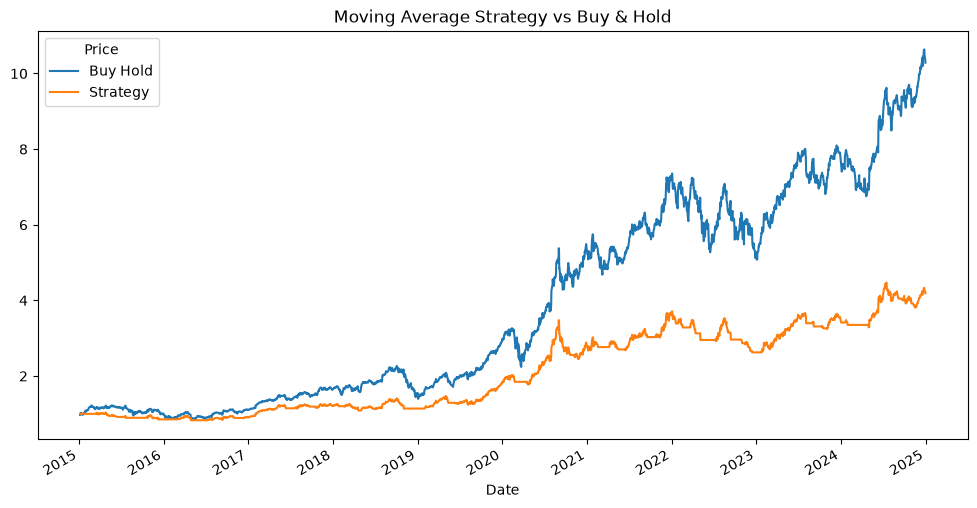

In [20]:
data[["Buy Hold","Strategy"]].plot(figsize=(12,6))

plt.title("Moving Average Strategy vs Buy & Hold")
plt.show()

In [21]:
data["Strategy"].iloc[-1]

np.float64(4.18944762906043)

In [22]:
data["Buy Hold"].iloc[-1]

np.float64(10.285382256062867)

In [23]:
rolling_max = data["Strategy"].cummax()

drawdown = data["Strategy"] / rolling_max - 1

drawdown.min()

np.float64(-0.2959514976930189)

In [24]:
final_value = data[["Buy Hold","Strategy"]].iloc[-1]

print("Buy & Hold:", round(final_value["Buy Hold"],2))
print("Strategy:", round(final_value["Strategy"],2))

print("Maximum Drawdown:", round(drawdown.min()*100,2), "%")

Buy & Hold: 10.29
Strategy: 4.19
Maximum Drawdown: -29.6 %


In [25]:
data["Signal"].value_counts()

Signal
1    1604
0     912
Name: count, dtype: int64

In [26]:
results = pd.DataFrame({
    "Strategy": [
        "Buy & Hold",
        "50 Day Moving Average"
    ],
    "Final Value": [
        data["Buy Hold"].iloc[-1],
        data["Strategy"].iloc[-1]
    ],
    "Maximum Drawdown": [
        (data["Buy Hold"] / data["Buy Hold"].cummax() - 1).min(),
        drawdown.min()
    ]
})

results

,Strategy,Final Value,Maximum Drawdown
0,Buy & Hold,10.285382,-0.385159
1,50 Day Moving Average,4.189448,-0.295951


In [27]:
data["200 Day MA"] = data["Close"].rolling(window=200).mean()

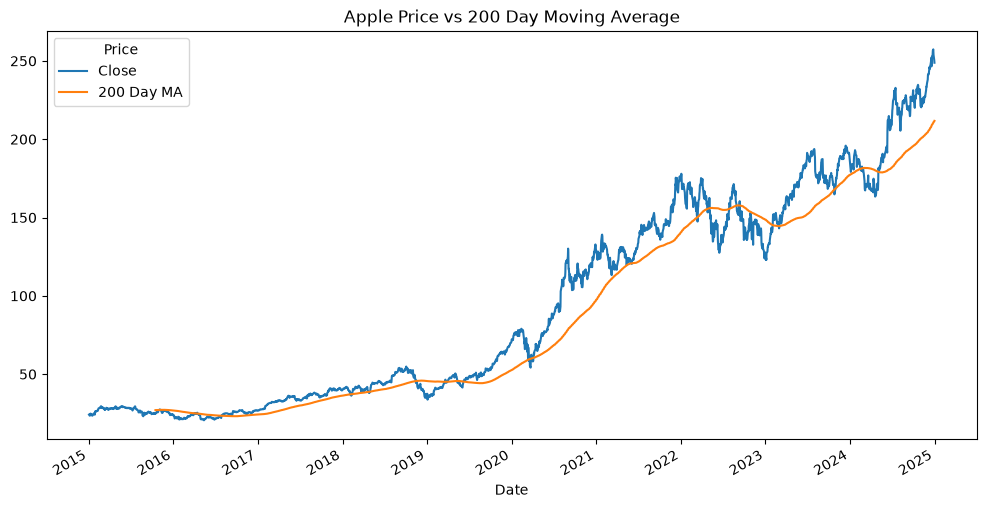

In [28]:
data[["Close","200 Day MA"]].plot(figsize=(12,6))

plt.title("Apple Price vs 200 Day Moving Average")
plt.show()

In [29]:
data["Signal_200"] = 0

data.loc[data["Close"] > data["200 Day MA"], "Signal_200"] = 1

In [30]:
data["Signal_200"].value_counts()

Signal_200
1    1780
0     736
Name: count, dtype: int64

In [31]:
data["Strategy_200_Return"] = data["Signal_200"].shift(1) * data["Daily Return"]

In [32]:
data["Strategy_200"] = (1 + data["Strategy_200_Return"]).cumprod()

In [33]:
rolling_max_200 = data["Strategy_200"].cummax()

drawdown_200 = data["Strategy_200"] / rolling_max_200 - 1

drawdown_200.min()

np.float64(-0.3531102372658165)

In [34]:
comparison = pd.DataFrame({
    "Buy Hold": [data["Buy Hold"].iloc[-1]],
    "50 Day MA": [data["Strategy"].iloc[-1]],
    "200 Day MA": [data["Strategy_200"].iloc[-1]]
})

comparison

,Buy Hold,50 Day MA,200 Day MA
0,10.285382,4.189448,4.933898


In [35]:
drawdowns = pd.DataFrame({
    "Buy Hold": [(data["Buy Hold"]/data["Buy Hold"].cummax()-1).min()],
    "50 Day MA": [drawdown.min()],
    "200 Day MA": [drawdown_200.min()]
})

drawdowns

,Buy Hold,50 Day MA,200 Day MA
0,-0.385159,-0.295951,-0.35311


In [36]:
years = (data.index[-1] - data.index[0]).days / 365.25

print("Years:", round(years,2))

Years: 10.0


In [37]:
cagr_buyhold = data["Buy Hold"].iloc[-1] ** (1/years) - 1
cagr_50 = data["Strategy"].iloc[-1] ** (1/years) - 1
cagr_200 = data["Strategy_200"].iloc[-1] ** (1/years) - 1

print("Buy Hold CAGR:", round(cagr_buyhold*100,2), "%")
print("50 Day MA CAGR:", round(cagr_50*100,2), "%")
print("200 Day MA CAGR:", round(cagr_200*100,2), "%")

Buy Hold CAGR: 26.26 %
50 Day MA CAGR: 15.41 %
200 Day MA CAGR: 17.31 %


In [38]:
vol_buyhold = data["Daily Return"].std() * np.sqrt(252)

vol_50 = data["Strategy Return"].std() * np.sqrt(252)

vol_200 = data["Strategy_200_Return"].std() * np.sqrt(252)

print("Buy Hold volatility:", round(vol_buyhold*100,2), "%")
print("50 Day MA volatility:", round(vol_50*100,2), "%")
print("200 Day MA volatility:", round(vol_200*100,2), "%")

Buy Hold volatility: 28.46 %
50 Day MA volatility: 19.15 %
200 Day MA volatility: 22.57 %


In [39]:
sharpe_buyhold = cagr_buyhold / vol_buyhold

sharpe_50 = cagr_50 / vol_50

sharpe_200 = cagr_200 / vol_200

print("Buy Hold Sharpe:", round(sharpe_buyhold,2))
print("50 Day MA Sharpe:", round(sharpe_50,2))
print("200 Day MA Sharpe:", round(sharpe_200,2))

Buy Hold Sharpe: 0.92
50 Day MA Sharpe: 0.8
200 Day MA Sharpe: 0.77
